# Eksperimen RMSNorm

Tujuan eksperimen ini: 
- Membandingkan model **tanpa normalisasi** vs **dengan RMSNorm**.
- Membandingkan hasil akhir prediksi.
- Membandingkan kurva training loss dan validation loss per epoch.
- Membandingkan distribusi bobot dan gradien pada beberapa/semua layer.

In [21]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.append(os.path.abspath('..'))

from data_prep import load_and_preprocess_data
from ffnn import FFNN

In [22]:
# Load data
data_path = Path.cwd().parent.parent / 'data' / 'global_student_placement_and_salary.csv'

X_train, y_train, X_val, y_val = load_and_preprocess_data(data_path)

num_classes = len(np.unique(y_train))
y_train_oh = np.eye(num_classes)[y_train]
y_val_oh = np.eye(num_classes)[y_val]

In [23]:
# Hyperparameters
layers = [X_train.shape[1], 32, 16, num_classes]
activations = ['relu', 'relu', 'softmax']
learning_rate = 0.01
batch_size = 32
epochs = 50

In [24]:
# Train model WITHOUT RMSNorm
model_base = FFNN(layers, activations, weight_initial='normal', use_rmsnorm=False)
history_base = model_base.fit(
    X_train, y_train_oh, X_val, y_val_oh,
    batch_size=batch_size,
    learning_rate=learning_rate,
    epochs=epochs,
    verbose=1,
    loss_type='categorical_crossentropy'
)

Epoch 50/50 [##############################] train_loss=0.531170 val_loss=0.546222


In [25]:
# Train model WITH RMSNorm
model_rms = FFNN(layers, activations, weight_initial='normal', use_rmsnorm=True)
history_rms = model_rms.fit(
    X_train, y_train_oh, X_val, y_val_oh,
    batch_size=batch_size,
    learning_rate=learning_rate,
    epochs=epochs,
    verbose=1,
    loss_type='categorical_crossentropy'
)

Epoch 50/50 [##############################] train_loss=0.520235 val_loss=0.545476


In [26]:
# Compare final predictions (accuracy)
def accuracy_from_logits(y_true_int, y_pred_probs):
    y_pred = np.argmax(y_pred_probs, axis=1)
    return np.mean(y_pred == y_true_int)

pred_base = model_base.forward(X_val)
pred_rms = model_rms.forward(X_val)

acc_base = accuracy_from_logits(y_val, pred_base)
acc_rms = accuracy_from_logits(y_val, pred_rms)

print(f'Accuracy (no RMSNorm): {acc_base:.4f}')
print(f'Accuracy (RMSNorm):   {acc_rms:.4f}')

Accuracy (no RMSNorm): 0.7160
Accuracy (RMSNorm):   0.7230


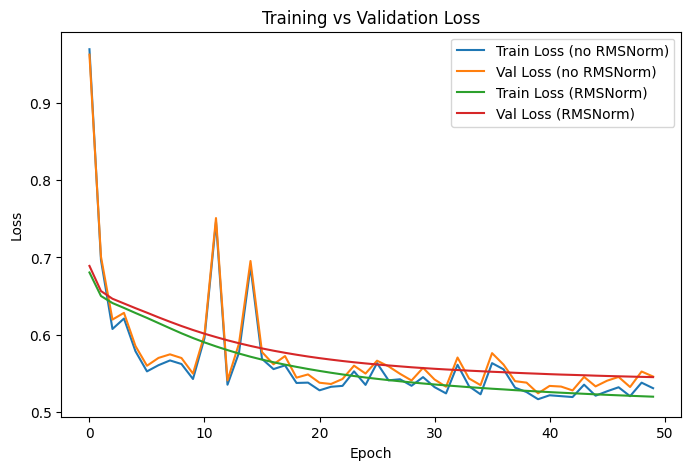

In [27]:
# Plot training and validation loss curves
plt.figure(figsize=(8, 5))
plt.plot(history_base['train_loss'], label='Train Loss (no RMSNorm)')
plt.plot(history_base['val_loss'], label='Val Loss (no RMSNorm)')
plt.plot(history_rms['train_loss'], label='Train Loss (RMSNorm)')
plt.plot(history_rms['val_loss'], label='Val Loss (RMSNorm)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

Weight distribution (no RMSNorm)


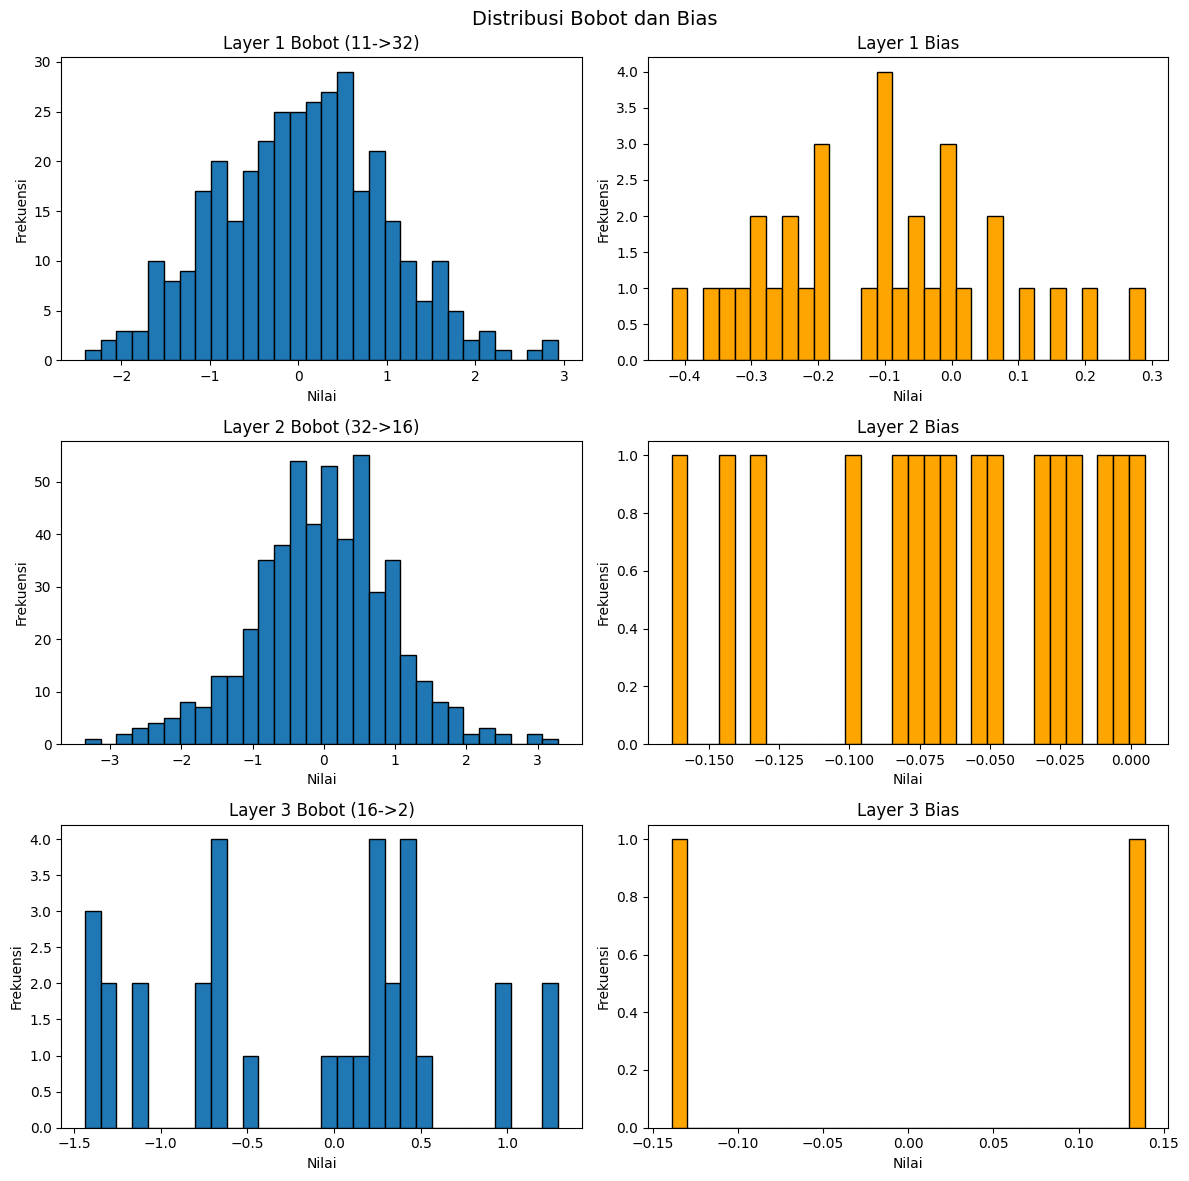

Weight distribution (RMSNorm)


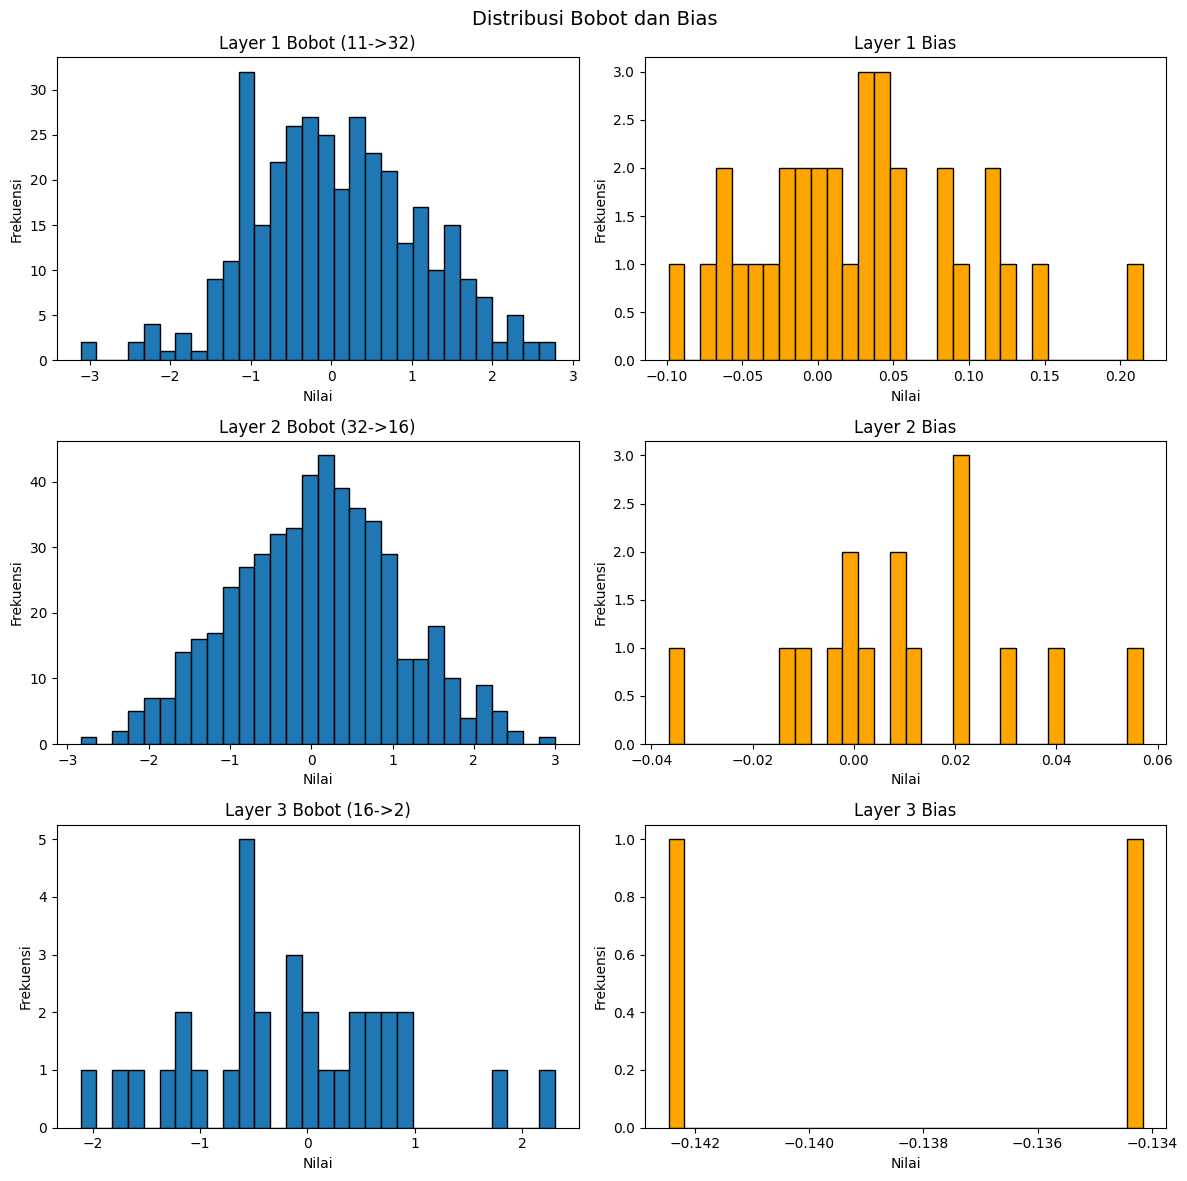

In [28]:
# Compare weight distributions
print('Weight distribution (no RMSNorm)')
model_base.plot_weight_distribution()

print('Weight distribution (RMSNorm)')
model_rms.plot_weight_distribution()

Gradient distribution (no RMSNorm)


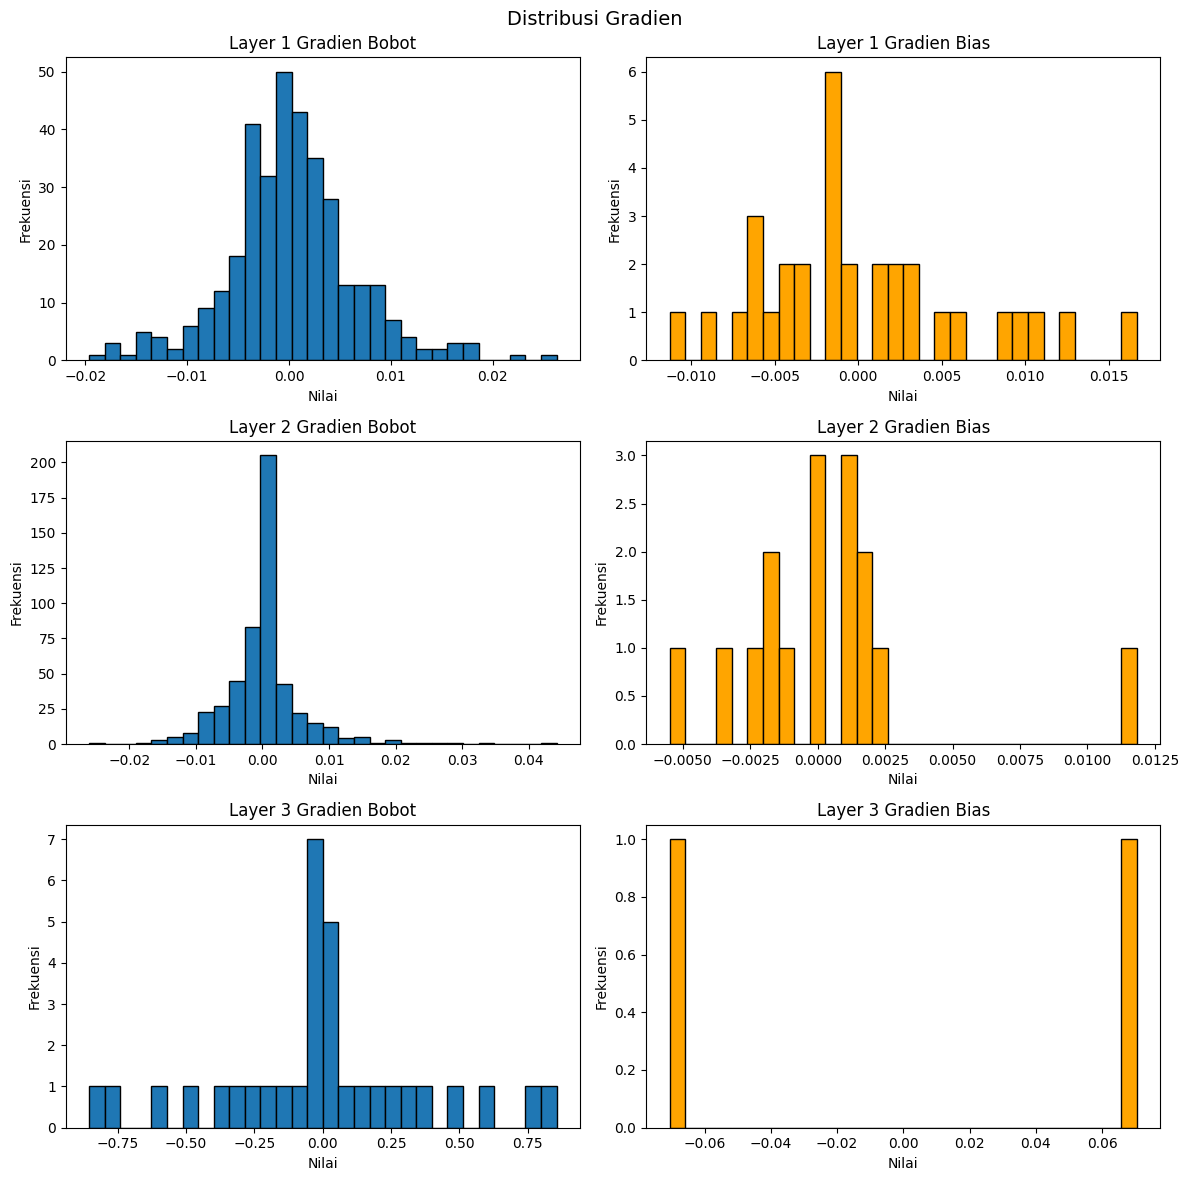

Gradient distribution (RMSNorm)


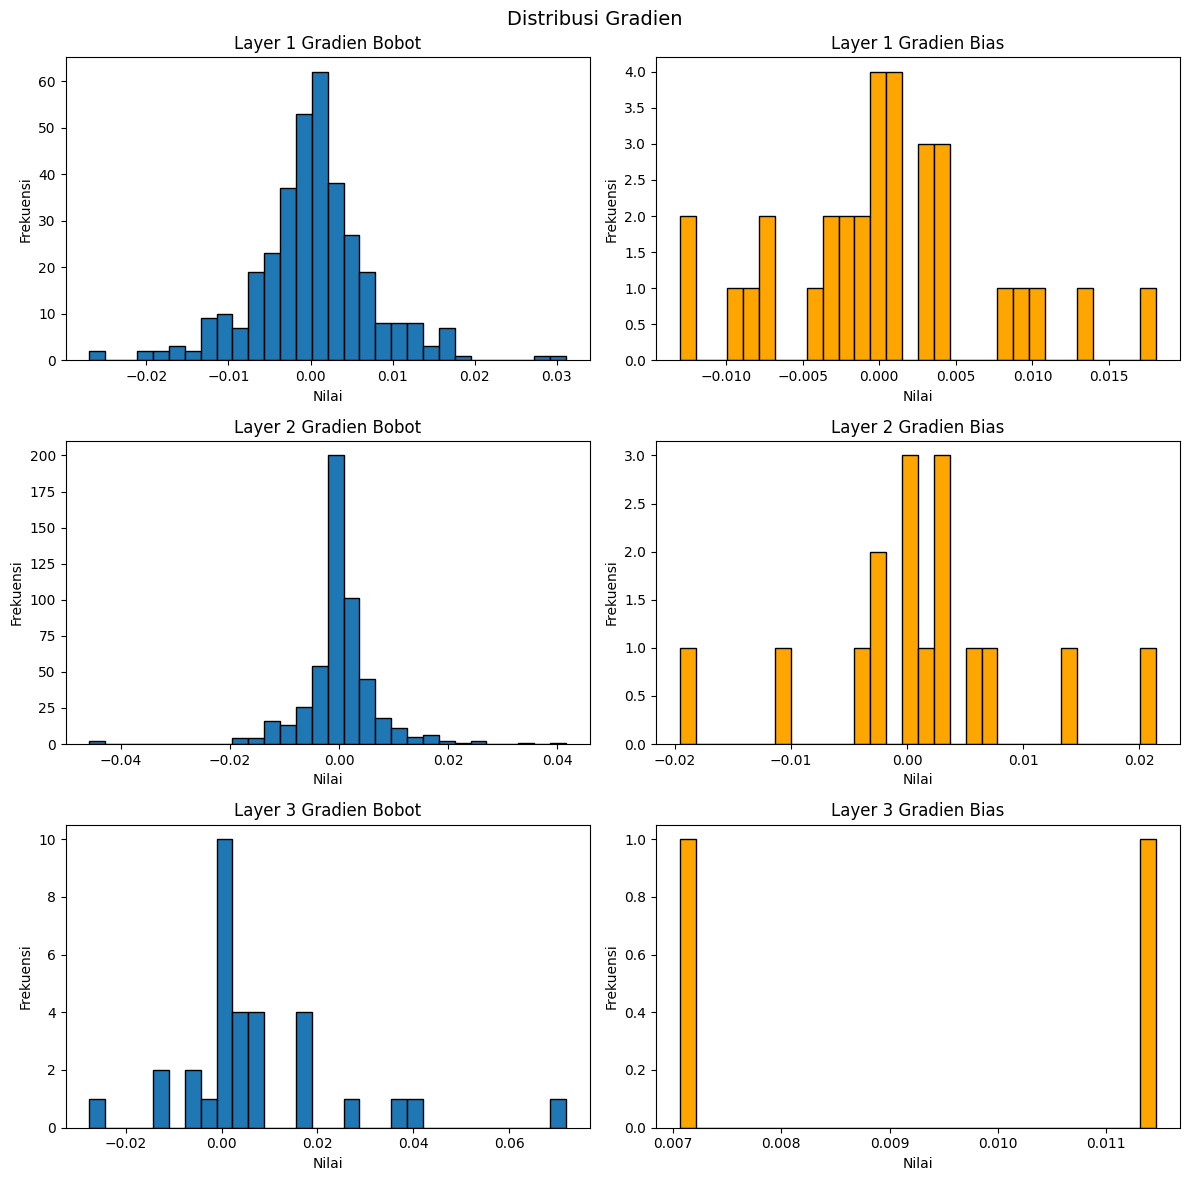

In [29]:
# Compare gradient distributions (run one backward pass to populate grads)
_ = model_base.forward(X_train[:batch_size])
model_base.backward(y_train_oh[:batch_size], loss_type='categorical_crossentropy')

_ = model_rms.forward(X_train[:batch_size])
model_rms.backward(y_train_oh[:batch_size], loss_type='categorical_crossentropy')

print('Gradient distribution (no RMSNorm)')
model_base.plot_gradient_distribution()

print('Gradient distribution (RMSNorm)')
model_rms.plot_gradient_distribution()